# Integration of SHMss events FL and CLL

In [1]:
#Load packages
# options(warn=-1)
library("IRdisplay")
library(tidyverse)
library(fs)
library(stringr)
library(viridis)
library(ggpubr)
library(ggplot2)
#library(ggExtra)
library(Seurat)
library(Biostrings) # this package interfer with dplyr
library(data.table)

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: viridisLite

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The s

In [2]:
suppressMessages(source("code/functions.R"))

## Load data

### Load and bind input data (all sequences) for K123B and K45678B

In [3]:
# df_seq1 <- Sys.glob("input/output_shm_v4up/FL/consensus/*/*.csv") %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
#       filter(ref_vdj_coverage == '1.0')
#   })

In [4]:
# df_seq2 <- Sys.glob("input/output_shm_20220819/*/consensus/*/*.csv")  %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
#       filter(ref_vdj_coverage == "1.0")
#   })

In [ ]:
cll_samples <- c("Q2_S356-HC","Q2_S356-LC","Q1_S5714-HC","Q1_S5714-LC","Q1_S7482-HC","Q1_S7482-LC",
                 "Q2_S4725-HC","Q2_S4725-LC","Q2_S9856-HC","Q2_S9856-LC")

df_seq3 <- Sys.glob("input/output_shm_v4up/MBL/consensus/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
      filter(ref_vdj_coverage == '1.0', subject %in% cll_samples)  
  })

In [ ]:
# df_seq <- bind_rows(df_seq1,df_seq2,df_seq3)

In [ ]:
# write.csv(df_seq, "output/UMI_consensus_all.csv",row.names = FALSE)

In [ ]:
# df_seq <- read.csv("output/UMI_consensus_all.csv")
# head(df_seq)

In [1]:
df_seq <- read.csv("output/UMI_consensus_K12345678.csv")
# head(df_seq,10)

In [2]:
head(df_seq,10)

,cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGTGTTTGC,AATTGACGCG,174,1,1,TTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTC,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;15;15;15;15;15;15;16;16;16;16;16;16;16;16;17;105;106;106;107;109;109;111;112;114;114;114;114;116;117;120;120;123;123;123;123;123;124;124;126;126;126;126;127;127;127;127;128;128;128;128;128;128;128;128;129;128;127;127;127;127;127;128;128;129;129;129;129;129;130;130;130;130;130;129;129;131;131;131;132;132;132;132;129;129;129;129;131;129;129;129;130;130;129;129;129;129;129;128;128;127;125;123;122;122;122;119;118;118;118;118;117;115;115;115;114;115;113;113;113;112;41;43;44;44;44;45;44;45;45;45;45;45;46;46;45;45;45;45;45;46;45;45;45;44;44;45;44;43;43;43;43;43;44;44;45;45;45;44;44;44;43;43;41;40;40;40;40;40;39;38;37;37;34;34;34;34;34;34;35;34;34;34;34;33;33;33;33;32;32;32;33;33;33;33;33;33;33;33;33;33;33;33;33;33;31;32;32;33;33;33;33;33;33;33;33;33;31;31;30;28;28;28;29;29;29;29;29;27;26;26;26;25;25;25;26;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;26;24;24;24;23;23;23;22;21;21;21;20;20;19;19;20;20;20;20;20;19;19;19;18;18;17;17;17;16;16;16;15;15;15;15;14;14;14;13;13;12;12;12;12;12;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;10;10;10;10;10;10;10;10;10;10;10;10;9;9;8;8;8;8;8;8;8;8;8;8;7;7;7;6;6;5;5;5;5;5;5;5;5;6;7;7;7;7;7;7;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;3;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,K1B_S10000-HC
2,AAACCTGGTCCAGTAT,ACCTCGAATG,109,1,1,ATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCC

In [3]:
umi_counts <- df_seq %>% mutate(case = str_extract(subject, "(?<=S)\\d+")) %>%
              mutate(gene = substr(subject, nchar(subject) - 1, nchar(subject))) %>%
              group_by(cell,case,gene) %>%
              summarise(umi_count = n(), gene = first(gene)) %>%
              ungroup()

ERROR: Error in df_seq %>% mutate(case = str_extract(subject, "(?<=S)\\d+")) %>% : could not find function "%>%"


In [4]:
umi_counts %>% pull(cell) %>% unique() %>% str()

ERROR: Error in umi_counts %>% pull(cell) %>% unique() %>% str(): could not find function "%>%"


In [5]:
umi_counts %>% filter(umi_count >= 5) %>% pull(cell) %>% unique() %>% str()

ERROR: Error in umi_counts %>% filter(umi_count >= 5) %>% pull(cell) %>% unique() %>% : could not find function "%>%"


In [73]:

# Summarize the data using the 'case_when()' approach for both UMI counts >= 5 and >= 10
summary_by_case <- umi_counts %>%
  # Group by case and cell to calculate UMI counts per cell per case
  group_by(case, cell) %>%
  summarise(
    has_HC_5 = case_when(
      any(gene == "HC" & umi_count >= 5) ~ TRUE,
      TRUE ~ FALSE
    ),  # HC with UMI count >= 5
    has_LC_5 = case_when(
      any(gene == "LC" & umi_count >= 5) ~ TRUE,
      TRUE ~ FALSE
    ),  # LC with UMI count >= 5
    has_HC_10 = case_when(
      any(gene == "HC" & umi_count >= 10) ~ TRUE,
      TRUE ~ FALSE
    ),  # HC with UMI count >= 10
    has_LC_10 = case_when(
      any(gene == "LC" & umi_count >= 10) ~ TRUE,
      TRUE ~ FALSE
    )   # LC with UMI count >= 10
  ) %>%
  ungroup() %>%
  # Summarize by case to calculate total counts for each condition
  group_by(case) %>%
  summarise(
    total_cells = n(), # Number of distinct cells per case
    # For UMI count >= 5
    VDJ_only_5 = sum(has_HC_5 & !has_LC_5),         # Cells with only HC (UMI >= 5)
    VJ_only_5 = sum(has_LC_5 & !has_HC_5),          # Cells with only LC (UMI >= 5)
    VDJ_and_VJ_5 = sum(has_HC_5 & has_LC_5),        # Cells with both HC and LC (UMI >= 5)
    VDJ_and_or_VJ_5 = sum(has_HC_5 | has_LC_5),     # Cells with either HC or LC (UMI >= 5)
    # For UMI count >= 10
    VDJ_only_10 = sum(has_HC_10 & !has_LC_10),       # Cells with only HC (UMI >= 10)
    VJ_only_10 = sum(has_LC_10 & !has_HC_10),        # Cells with only LC (UMI >= 10)
    VDJ_and_VJ_10 = sum(has_HC_10 & has_LC_10),      # Cells with both HC and LC (UMI >= 10)
    VDJ_and_or_VJ_10 = sum(has_HC_10 | has_LC_10),   # Cells with either HC or LC (UMI >= 10)
    .groups = "drop" # Drop the grouping at the end
  )

# Print the summary by case
print(summary_by_case)



`summarise()` has grouped output by 'case'. You can override using the `.groups` argument.


# A tibble: 12 × 10
   case  total_cells VDJ_only_5 VJ_only_5 VDJ_and_VJ_5 VDJ_and_or_VJ_5
   <chr>       <int>      <int>     <int>        <int>           <int>
 1 10000        8938         48      1625         6996            8669
 2 10971        1089          0       209            0             209
 3 11770         215          0        30            0              30
 4 12118         848         57       358          148             563
 5 12282         400          1       264           36             301
 6 12390        1589        110       545          104             759
 7 12500        2489        397       265         1422            2084
 8 13530        8389         21       218         8105            8344
 9 13553        8214         28      5063         2502            7593
10 144          1489         16      1030          271            1317
11 8382         1216         17       614           62             693
12 8934        16432         61      8815         6192   

In [84]:
summary_by_case

case,total_cells,VDJ_only_5,VJ_only_5,VDJ_and_VJ_5,VDJ_and_or_VJ_5,VDJ_only_10,VJ_only_10,VDJ_and_VJ_10,VDJ_and_or_VJ_10
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
10000,8938,48,1625,6996,8669,82,1978,6154,8214
10971,1089,0,209,0,209,0,18,0,18
11770,215,0,30,0,30,0,2,0,2
12118,848,57,358,148,563,19,322,31,372
12282,400,1,264,36,301,0,194,9,203
12390,1589,110,545,104,759,4,211,2,217
12500,2489,397,265,1422,2084,391,231,867,1489
13530,8389,21,218,8105,8344,60,529,7663,8252
13553,8214,28,5063,2502,7593,17,5926,538,6481


In [102]:
# Define conditions grouped by case
summary_by_case <- umi_counts %>%
  group_by(case, cell) %>% # Group by case and cell
  summarise(
    has_HC = any(gene == "HC" & umi_count >= 5),
    has_LC = any(gene == "LC" & umi_count >= 5)
  ) %>%
  summarise(
    total_cells = n(),
    VDJ_only = sum(has_HC & !has_LC),        # Cells with only HC
    VJ_only = sum(has_LC & !has_HC),        # Cells with only LC
    VDJ_and_VJ = sum(has_HC & has_LC),      # Cells with both HC and LC
    VDJ_and_or_VJ = sum(has_HC | has_LC)    # Cells with either HC or LC
  ) %>%
  ungroup() # Remove grouping

# Print the summary by case
print(summary_by_case)

`summarise()` has grouped output by 'case'. You can override using the `.groups` argument.


# A tibble: 12 × 6
   case  total_cells VDJ_only VJ_only VDJ_and_VJ VDJ_and_or_VJ
   <chr>       <int>    <int>   <int>      <int>         <int>
 1 10000        8938       48    1625       6996          8669
 2 10971        1089        0     209          0           209
 3 11770         215        0      30          0            30
 4 12118         848       57     358        148           563
 5 12282         400        1     264         36           301
 6 12390        1589      110     545        104           759
 7 12500        2489      397     265       1422          2084
 8 13530        8389       21     218       8105          8344
 9 13553        8214       28    5063       2502          7593
10 144          1489       16    1030        271          1317
11 8382         1216       17     614         62           693
12 8934        16432       61    8815       6192         15068


In [97]:
umi_counts %>%
  group_by(cell) %>%
  filter(case == "10000", cell == "ACACCCTCAGCGTCCA")

cell,case,gene,umi_count
<chr>,<chr>,<chr>,<int>
ACACCCTCAGCGTCCA,10000,HC,25
ACACCCTCAGCGTCCA,10000,LC,8


### Load doublets

In [4]:
# #read doublet table
# dou_k123 <- read.csv("output/doublet_in_K123_v1.csv") 

In [6]:
# #read doublet table
# dou_k45678 <- read.csv("output/doublet_in_K45678.csv") %>% select(-X,-SHMa_pos)

In [8]:
#read doublet table
#doublet_cll <- read.csv("output/doublet_in_CLL_MBL.csv")

In [10]:
# doublet <- bind_rows(dou_k45678,dou_k123,doublet_cll)

In [11]:
#write.csv(doublet, "output/doublet_all.csv",row.names = FALSE)

In [7]:
doublet <- read.csv("output/doublet_all.csv")

In [13]:
# positive doublet table

doublet_pos <- doublet %>% filter(scDblFinder.class == "doublet")
head(doublet_pos)

,cell,experiment,scDblFinder.class,scDblFinder.score,nCount_RNA,nFeature_RNA
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>
1,AAACGGGCAGCAGTTT,K4B,doublet,0.9345188,4354,1837
2,AAAGATGCAAAGGTGC,K4B,doublet,0.9996318,6286,2318
3,AAAGCAAAGAAGGACA,K4B,doublet,0.6476811,3260,1390
4,AAAGCAACATCGTCGG,K4B,doublet,0.5904164,2341,1148
5,AAAGCAAGTAATCACC,K4B,doublet,0.8558691,8150,2254
6,AAAGCAATCCCAGGTG,K4B,doublet,0.4669521,3331,1442


### Load all SHMss events detected (positive + false positive)

In [86]:
# df1 <- Sys.glob("input/shm_incl_po_subrg.20210912/FL/*/*.csv") %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "ccicccilciiccc", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
#   })

In [87]:
# # load data
# df2 <- Sys.glob("input/output_shm_20220819/shm_incl_po/*/*.csv") %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "ccicccilciicc", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
#   })

In [93]:
# cll_samples <- c("Q2_S356-HC","Q2_S356-LC","Q1_S5714-HC","Q1_S5714-LC","Q1_S7482-HC","Q1_S7482-LC",
#                  "Q2_S4725-HC","Q2_S4725-LC","Q2_S9856-HC","Q2_S9856-LC")

# df3 <- Sys.glob("input/shm_incl_po_subrg.20210912/CLLMBL/*/*.csv") %>%
#   purrr::map_dfr(function(x) {
#     readr::read_csv(x, col_types = "ccicccilciiccc", progress = FALSE) %>%
#       dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x)) %>% filter(subject %in% cll_samples)
#   })

In [94]:
# df <- bind_rows(df1,df2,df3)

In [95]:
# write.csv(df, "output/shm_all.csv",row.names = FALSE)

In [3]:
df <- read.csv("output/shm_all.csv")

In [ ]:
df_new <- Sys.glob("input/results_20230728/FL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciiccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

In [ ]:
head(df_new,-50)

### Filter doublet

In [7]:
# get_n_events <- function(df) {
#   nrow(df %>% dplyr::count(subject, cell, position))
# }

# get_n_cells <- function(df) {  # we should use case because sometimes there are events in HC and LC of a same cell
#   nrow(df %>% mutate(case =gsub(".{3}$", "", subject)) %>%
#    group_by(case) %>%
#    dplyr::count(case, cell))
# }

# #save df without modification
# dfo<- df

# stats <- data.frame(step = c("Unfiltered"), n = c(get_n_events(df)), cell=c(get_n_cells(df)))


# # f1. filter by doublet

# ## Include a variable expriment to can filter with the doublet table
# df <- df %>% mutate(experiment = str_sub(subject, 1, 3))

# df <- df %>% anti_join(doublet_pos, 
#             by=c('cell','experiment'))

# # filter values
# c.region <- c("V","D","J")
# c.min_depth <- 5
# c.min_umis <- 10 
# c.min_2nd_ratio <- 0.2
# c.max_cells_with_same_variation<- 1


# stats <- stats %>%
#   add_row(step = "After F1", n = get_n_events(df), cell=c(get_n_cells(df)))

In [9]:
#write.csv(df, "output/shm_all_filter_doublet.csv",row.names = FALSE) #for David

### Load df with filtered SHMss events (trully positive)

In [13]:
# df_summary1 <- readr::read_csv("output/df_summary_K123_v3.csv", col_types = "ccicccccc", progress = FALSE)
# str(df_summary1)

In [14]:
# df_summary2 <- read.csv("output/df_summary_K45678_v7.csv") 
# str(df_summary2)

In [11]:
# df_summary <- df_summary1 %>% bind_rows(df_summary2)

In [12]:
# write.csv(df_summary, "output/df_summary_K12345678_v3.csv",row.names = FALSE)

In [3]:
df_summary <- read.csv("output/df_summary_K12345678_v3.csv")

In [9]:
str(df_summary)

'data.frame':	1239 obs. of  9 variables:
 $ subject               : chr  "K1B_S10000-LC" "K1B_S10000-LC" "K1B_S10000-LC" "K1B_S10000-LC" ...
 $ cell                  : chr  "AGCTTGACAATGGACG" "AGCTTGACAATGGACG" "CTAGCCTCAATCACAC" "CGAGCACAGGTTCCTA" ...
 $ vgene_position_aligned: int  28 56 60 78 4 18 25 29 39 40 ...
 $ nucl_po               : chr  "G" "C" "C" "C" ...
 $ context_po            : chr  "CA.TG" "CA.CA" "AT.TC" "AG.TC" ...
 $ subregion             : chr  "FR1" "FR1" "FR1" "CDR1" ...
 $ variation             : chr  "A-G" "A-C" "C-G" "C-T" ...
 $ umis                  : chr  "12-14" "12-14" "11-14" "20-32" ...
 $ productive            : chr  "TRUE" "TRUE" "TRUE" "TRUE" ...


### Load Umis

In [ ]:
df_umis <-  read.csv("output/df_umis_K45678.csv")  %>% bind_rows(read.csv("output/df_umis_K123.csv"))

In [11]:
#write.csv(df_umis, "output/df_umis.csv",row.names = FALSE)

## 2. Downstream analysis

In [21]:
my_favorite_colors <- c(
  "#4266ee",
  # "#8aa0f4",
  "#3CBBB1",
  "#91dcd6",
  "#ff6525",
  "#FF9B71",
  "#ffc4ac",
  "#ffeee7"
)

### A) How many events by subject?

In [5]:
df_summary_by_subject <- df_summary %>% mutate(case =gsub(".{3}$", "", subject)) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  dplyr::count(case,gene)

df_summary_by_subject

case,gene,n
<chr>,<chr>,<int>
K1B_S10000,LC,4
K1B_S144,LC,116
K2B_S11770,LC,1
K2B_S12500,HC,1
K2B_S12500,LC,1
K2B_S13530,LC,5
K2B_S13553,LC,11
K4B_S8934,HC,3
K5B_S8934,HC,1


In [24]:
df_summary_by_case <- df_summary %>% mutate(case = str_extract(subject, "(?<=_)[^\\-]+")) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  dplyr::count(case)

df_summary_by_case

case,n
<chr>,<int>
S10000,394
S11770,1
S12500,2
S13530,400
S13553,322
S144,116
S8934,4


In [12]:
print("Number of events")
sum(df_summary_by_subject$n)

[1] "Number of events"


[1] 1239

In [14]:
df_summary_by_case<- df_summary %>% mutate(case =gsub(".{3}$", "", subject)) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  dplyr::count(case) %>%
  dplyr::rename(Total_events=n)

print("Number of TOTAL events by case")
df_summary_by_case

[1] "Number of TOTAL events by case"


case,Total_events
<chr>,<int>
K1B_S10000,4
K1B_S144,116
K2B_S11770,1
K2B_S12500,2
K2B_S13530,5
K2B_S13553,11
K4B_S8934,3
K5B_S8934,1
K6B_S13530,395


### B) How many cells have SHMacting by subject?

### Amount of cell by case with SHMxx

In [25]:
# shm_cell_case <- df_summary %>% 
#    mutate(case =gsub(".{3}$", "", subject),Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>%
#    group_by(case, Patient_id) %>%
#    summarise(scSHM_cell = n_distinct(cell))

In [26]:
head(df_summary)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,K1B_S10000-LC,AGCTTGACAATGGACG,28,G,CA.TG,FR1,A-G,12-14,TRUE
2,K1B_S10000-LC,AGCTTGACAATGGACG,56,C,CA.CA,FR1,A-C,12-14,TRUE
3,K1B_S10000-LC,CTAGCCTCAATCACAC,60,C,AT.TC,FR1,C-G,11-14,TRUE
4,K1B_S10000-LC,CGAGCACAGGTTCCTA,78,C,AG.TC,CDR1,C-T,20-32,TRUE
5,K1B_S144-LC,ATCATGGGTGGTCTCG,4,A,AC.TC,FR1,A-T,12-23,TRUE
6,K1B_S144-LC,TCTTTCCGTCTAGTCA,18,G,CA.TC,FR1,A-G,27-18,TRUE


In [35]:
shm_cell_patient <- df_summary %>% 
   mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>% mutate(gene = substr(subject, nchar(subject) - 1, nchar(subject))) %>%
   group_by(Patient_id,gene) %>%
   summarise(scSHM_cell = n_distinct(cell), .groups = "drop")

In [36]:
shm_cell_patient

Patient_id,gene,scSHM_cell
<chr>,<chr>,<int>
S10000,HC,54
S10000,LC,96
S11770,LC,1
S12500,HC,1
S12500,LC,1
S13530,HC,60
S13530,LC,56
S13553,LC,103
S144,LC,40


In [17]:
case_cell <- df_seq %>% 
   mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"),diagnosis = case_when(subject %like% "K" ~ "FL",
                         subject %like% "Q" ~ "CLL",
                         TRUE ~ NA)) %>%
   group_by(diagnosis,Patient_id) %>%
    summarise(total_cell = n_distinct(cell)) %>%
    left_join(shm_cell_patient, by='Patient_id') %>%
    replace(is.na(.), 0) %>%
   mutate(Percentage =scSHM_cell * 100 / total_cell)
case_cell

ERROR: Error in mutate(., Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"), : object 'df_seq' not found


In [ ]:
print("Frequency of events by patient")
case_cell %>%
  summarize(mean_myvar = mean(Percentage),
            median_myvar = median(Percentage),
            sd_myvar = sd(Percentage),
            min_myvar = min(Percentage),
            max_myvar = max(Percentage))

In [ ]:
print("Average of total cells by patient")
case_cell %>%
 ungroup() %>%
  summarize(mean_myvar = mean(total_cell),
            median_myvar = median(total_cell),
            sd_myvar = sd(total_cell),
            min_myvar = min(total_cell),
            max_myvar = max(total_cell))

In [ ]:
# Total number of cells

print("Number of TOTAL cells with events")
case_cell %>% pull(scSHM_cell) %>% sum()

### C) How many positions have SHMacting by subject?"

In [32]:
c_pos <-df_summary %>%
  mutate(case =gsub(".{3}$", "", subject)) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  group_by(case,gene) %>%
  summarise(n_pos = n_distinct(vgene_position_aligned))

c_pos

`summarise()` has grouped output by 'case'. You can override using the `.groups` argument.


case,gene,n_pos
<chr>,<chr>,<int>
K1B_S10000,LC,4
K1B_S144,LC,64
K2B_S11770,LC,1
K2B_S12500,LC,1
K2B_S13553,LC,10
K4B_S8934,HC,3
K5B_S8934,HC,1
K6B_S13530,HC,60
K6B_S13530,LC,38


### Master table

In [33]:
case_cell

diagnosis,Patient_id,total_cell,scSHM_cell,Percentage
<chr>,<chr>,<int>,<int>,<dbl>
CLL,S356,1027,0,0.00000000
CLL,S4725,1112,0,0.00000000
CLL,S5714,1069,0,0.00000000
CLL,S7482,644,0,0.00000000
CLL,S9856,587,0,0.00000000
FL,S10000,8938,123,1.37614679
FL,S10971,1089,0,0.00000000
FL,S11770,215,1,0.46511628
FL,S12118,848,0,0.00000000


In [34]:
df_summary_by_subject %>% 
          right_join(df_summary_by_case, by = "case") 

case,gene,n,Total_events
<chr>,<chr>,<int>,<int>
K1B_S10000,LC,4,4
K1B_S144,LC,101,101
K2B_S11770,LC,1,1
K2B_S12500,LC,1,1
K2B_S13553,LC,11,11
K4B_S8934,HC,3,3
K5B_S8934,HC,1,1
K6B_S13530,HC,183,365
K6B_S13530,LC,182,365


In [35]:
summary <- df_summary_by_subject %>% 
          right_join(df_summary_by_case, by = "case") %>%
          right_join(case_cell, by = "case") %>%
#           left_join(c_pos, by = c("case", "gene")) %>%
           dplyr::rename(Patient=case) %>%
#           select(-subject) %>%
           pivot_wider(names_from="gene", values_from="n") %>%
           select(Patient,total_cell,scSHM_cell,Percentage,Total_events,everything()) %>% #, 
           replace(is.na(.), 0) %>%
           dplyr::rename(event_HC=HC, event_LC=LC)

write.csv(summary, "output/summary_all.csv")
summary

ERROR: [1m[33mError[39m in `right_join()`:[22m
[1m[22m[33m![39m Join columns in `y` must be present in the data.
[31m✖[39m Problem with `case`.


### D) Number of event (positions) by cell

In [4]:
#pos by cell
pbc <- df_summary %>% #filter(source == "K2B_S12500_L")
   group_by(subject, cell) %>%
   summarise(pos_by_cell = n_distinct(vgene_position_aligned)) %>%
   mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)"))
head(pbc)

`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


subject,cell,pos_by_cell,case
<chr>,<chr>,<int>,<chr>
K1B_S10000-LC,AGCTTGACAATGGACG,2,S10000
K1B_S10000-LC,CGAGCACAGGTTCCTA,1,S10000
K1B_S10000-LC,CTAGCCTCAATCACAC,1,S10000
K1B_S144-LC,AACCGCGAGGTGCTAG,1,S144
K1B_S144-LC,AACTCAGCATTCGACA,1,S144
K1B_S144-LC,AAGGTTCGTTGTACAC,3,S144


In [5]:
#df_summary %>% mutate(gene = substr(subject, nchar(subject) - 1, nchar(subject)))

In [6]:
pbc %>% group_by(pos_by_cell) %>% summarize(n=n()) %>% mutate(percentage= n * 100 / sum(n))

pos_by_cell,n,percentage
<int>,<int>,<dbl>
1,109,26.2019231
2,106,25.4807692
3,61,14.6634615
4,56,13.4615385
5,35,8.4134615
6,27,6.4903846
7,12,2.8846154
8,6,1.4423077
9,3,0.7211538


In [7]:
pbc2 <- df_summary %>% mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)"),gene = substr(subject, nchar(subject) - 1, nchar(subject)), experiment = str_sub(subject, 1, 3)) %>%
   group_by(experiment,case, cell,gene) %>%
   summarise(pos_by_cell = n_distinct(vgene_position_aligned)) 
head(pbc2)

`summarise()` has grouped output by 'experiment', 'case', 'cell'. You can
override using the `.groups` argument.


experiment,case,cell,gene,pos_by_cell
<chr>,<chr>,<chr>,<chr>,<int>
K1B,S10000,AGCTTGACAATGGACG,LC,2
K1B,S10000,CGAGCACAGGTTCCTA,LC,1
K1B,S10000,CTAGCCTCAATCACAC,LC,1
K1B,S144,AACCGCGAGGTGCTAG,LC,1
K1B,S144,AACTCAGCATTCGACA,LC,1
K1B,S144,AAGGTTCGTTGTACAC,LC,3


In [14]:
events_by_cell <- pbc2 %>% group_by(experiment,case,pos_by_cell) %>% summarize(n=n())
head(events_by_cell)

`summarise()` has grouped output by 'experiment', 'case'. You can override
using the `.groups` argument.


experiment,case,pos_by_cell,n
<chr>,<chr>,<int>,<int>
K1B,S10000,1,2
K1B,S10000,2,1
K1B,S144,1,13
K1B,S144,2,6
K1B,S144,3,7
K1B,S144,4,7


In [39]:
case_color = c("#85d3ee","#fdc681","#cdadbe","#899bce")

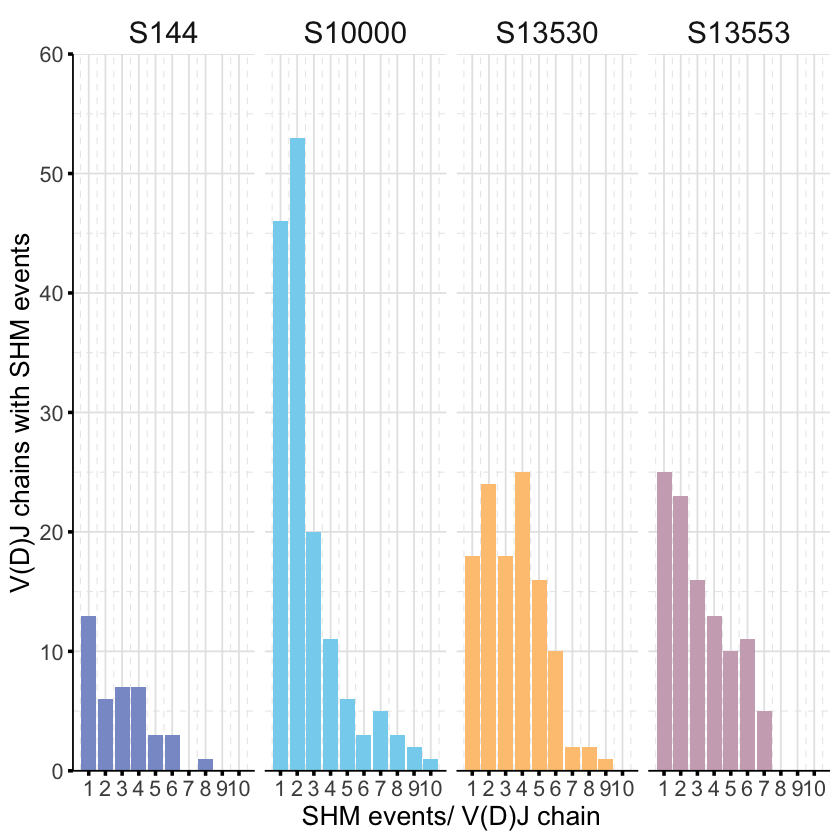

In [79]:
# Create the bar plot
plot <- ggplot(events_by_cell %>% filter(case %in% c("S144","S10000","S13530","S13553")), aes(x = 	pos_by_cell, y = n, fill = case)) +
  geom_bar(stat = "identity") +  # Create bars based on summed 'n'
  scale_x_continuous(breaks = unique(events_by_cell$pos_by_cell)) +
    scale_y_continuous(limits = c(0, 60),expand = c(0, 0),minor_breaks = seq(0, 60, by = 5)) +
  scale_fill_manual(values = case_color) +
  labs(x = "SHM events/ V(D)J chain", y = "V(D)J chains with SHM events") +
  theme_minimal(base_size = 12) +
  theme(
    axis.text = element_text(size = 13),  # Customize axis text size
    axis.title = element_text(size = 16),  # Customize axis title size
    strip.text = element_text(size = 17),
    legend.position = "none",# Center plot title
   panel.grid.major = element_line(color = "gray90", size = 0.5),  # Major grid lines
    panel.grid.minor = element_line(color = "gray90", size = 0.25, linetype = "dashed"),  # Minor grid lines
  axis.line = element_line(color = "black", size = 0.5),
  axis.ticks = element_line(color = "black", size = 1)) +  facet_wrap(. ~ factor(case, levels = c("S144", "S10000", "S13530", "S13553")),nrow = 1)

# Display the plot
plot

In [80]:
# Save the plot for publication
ggsave("figs_paper/events_by_cell_2025.pdf", plot, width = 19, height = 9, units = "cm", dpi = 320)
ggsave("figs_paper/events_by_cell_2025.png", plot, width = 19, height = 9, units = "cm", dpi = 320)

In [50]:
events_all_by_cell <- pbc2 %>% group_by(pos_by_cell) %>% summarize(n=n())
head(events_all_by_cell,10)

pos_by_cell,n
<int>,<int>
1,109
2,106
3,61
4,56
5,35
6,27
7,12
8,6
9,3


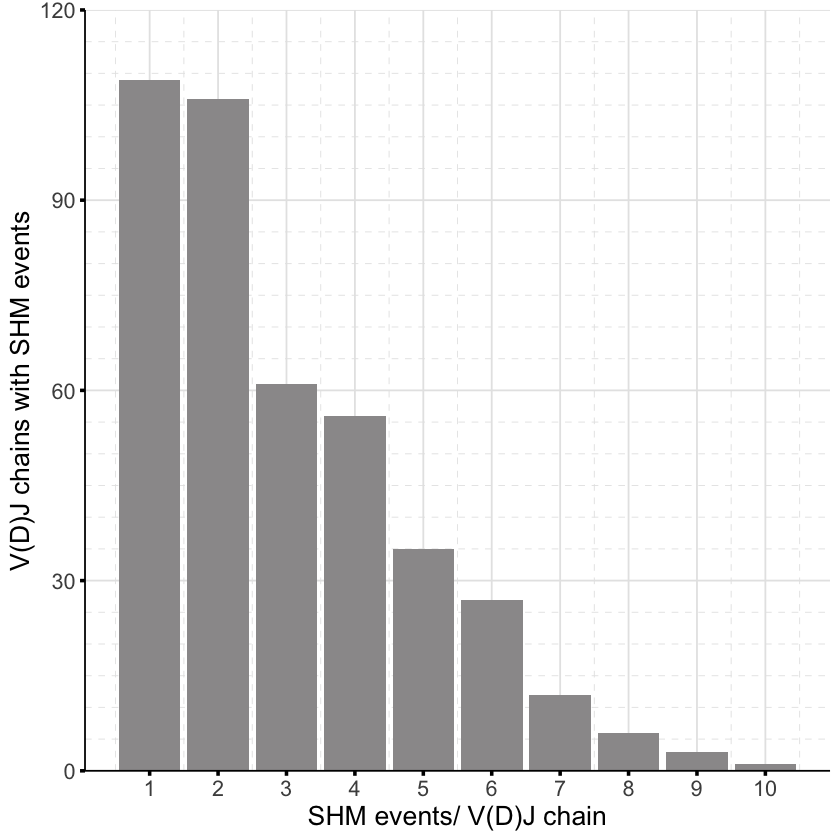

In [68]:
# Create the bar plot
plot <- ggplot(events_all_by_cell, aes(x = 	pos_by_cell, y = n)) +
  geom_bar(stat = "identity", fill = "#9b999a") +  # Create bars based on summed 'n'
  scale_x_continuous(breaks = unique(events_by_cell$pos_by_cell)) +
  scale_y_continuous(limits = c(0, 120),expand = c(0, 0),minor_breaks = seq(0, 120, by = 5)) +
  labs(x = "SHM events/ V(D)J chain", y = "V(D)J chains with SHM events") +
  theme_minimal(base_size = 12) +
  theme(
    axis.text = element_text(size = 13),  # Customize axis text size
    axis.title = element_text(size = 16),  # Customize axis title size
    legend.position = "none",# Center plot title
   panel.grid.major = element_line(color = "gray90", size = 0.5),  # Major grid lines
    panel.grid.minor = element_line(color = "gray90", size = 0.25, linetype = "dashed"),  # Minor grid lines

   axis.line = element_line(color = "black", size = 0.5),
      axis.ticks = element_line(color = "black", size = 1)
  
  ) 

# Display the plot
plot

In [69]:
# Save the plot for publication
ggsave("figs_paper/events_all_by_cell_2025.pdf", plot, width = 10, height = 12, units = "cm", dpi = 320)
ggsave("figs_paper/events_all_by_cell_2025.png", plot, width = 10, height = 12, units = "cm", dpi = 320)

### Calcultaion event in Vj or VDJ or both

In [11]:
df_summary

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
K1B_S10000-LC,AGCTTGACAATGGACG,28,G,CA.TG,FR1,A-G,12-14,TRUE
K1B_S10000-LC,AGCTTGACAATGGACG,56,C,CA.CA,FR1,A-C,12-14,TRUE
K1B_S10000-LC,CTAGCCTCAATCACAC,60,C,AT.TC,FR1,C-G,11-14,TRUE
K1B_S10000-LC,CGAGCACAGGTTCCTA,78,C,AG.TC,CDR1,C-T,20-32,TRUE
K1B_S144-LC,ATCATGGGTGGTCTCG,4,A,AC.TC,FR1,A-T,12-23,TRUE
K1B_S144-LC,TCTTTCCGTCTAGTCA,18,G,CA.TC,FR1,A-G,27-18,TRUE
K1B_S144-LC,ACGCCAGAGGCATTGG,25,T,CA.CC,FR1,C-T,14-17,TRUE
K1B_S144-LC,CACATAGTCATACGGT,29,C,CT.CC,FR1,C-T,70-36,TRUE
K1B_S144-LC,TGTGGTAAGGCGACAT,39,A,GC.TC,FR1,A-T,11-15,TRUE


In [15]:
df_summary %>% mutate(gene = substr(subject, nchar(subject) - 1, nchar(subject)), case = str_extract(subject, "(?<=_)[^_]+(?=-)"), experiment = str_sub(subject, 1, 3)) %>% 
select(experiment,case, cell, gene, vgene_position_aligned,variation) %>%
  distinct(experiment,case, cell, gene) %>%   # Eliminar duplicados por 'case', 'cell' y 'gene'
  group_by(experiment,case, cell) %>%        # Agrupar por 'case' y 'cell'
  summarise(
    genes_present = paste(sort(unique(gene)), collapse = ","), # Ordenar genes al concatenar
    .groups = "drop"
  ) %>%
  mutate(category = case_when(
    genes_present %in% c("LC", "HC") ~ paste("Only", genes_present),  # Single gene cases
    genes_present %in% c("HC,LC", "LC,HC") ~ "Both",                  # Consider both orders
    TRUE ~ "Other"
  )) %>%
  group_by(experiment,case, category) %>%
  summarise(count = n(), .groups = "drop")

experiment,case,category,count
<chr>,<chr>,<chr>,<int>
K1B,S10000,Only LC,3
K1B,S144,Only LC,40
K2B,S11770,Only LC,1
K2B,S12500,Both,1
K2B,S13530,Only LC,2
K2B,S13553,Only LC,8
K4B,S8934,Only HC,3
K5B,S8934,Only HC,1
K6B,S13530,Both,29


#### number of event by chain

In [18]:
head(pbc2 %>% group_by(pos_by_cell,experiment,case,gene) %>% summarize(n=n()) %>% mutate(percentage= n * 100 / sum(n)))

ERROR: [1m[33mError[39m in `group_by()`:[22m
[1m[22m[33m![39m Must group by variables found in `.data`.
[31m✖[39m Column `experiment` is not found.


In [35]:
## 3. Visualizations

# # prepare df foe new plots
# df_filter_vis <- df_summary %>% 
#             separate(variation, c("variation1", "variation2"), "-",remove = FALSE) %>%
#             separate(umis, c("umis1", "umis2"), "-",remove = FALSE, convert= TRUE)%>%
#             mutate(umis2 = umis2 * -1) %>%
#             gather('umis1', 'umis2',key='umi_nu',value="umi") %>%
#             mutate(nucleotide = if_else(umi_nu == "umis1", variation1,variation2)) %>%
#             mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>%
#             group_by(case) %>%
#             mutate(cell_no = paste0("Cell ",as.integer(factor(cell)))) #%>%
# #            left_join(df %>% select(cell,vgene_position_aligned,subject,context), by=c('cell','vgene_position_aligned','subject'))
# #            gather('variation1', 'variation2',key='variation_type',value="nucleotide")

## Overview

In [36]:
#read expression summary data
shm_perc_sub <- read.csv("output/expresion_data_perc_sub_K45678_cat.csv")

In [37]:
head(shm_perc_sub)

,subject,gene,group,expression,count,perc,pathway
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>
1,S10000,ADAR,SHMss_observed,No,37,42.04545,RNSA_editing
2,S10000,ADAR,SHMss_observed,Yes,51,57.95455,RNSA_editing
3,S10000,ADAR,SHMss_not_observed,No,56,72.72727,RNSA_editing
4,S10000,ADAR,SHMss_not_observed,Yes,21,27.27273,RNSA_editing
5,S10000,AICDA,SHMss_observed,No,45,51.13636,SHM
6,S10000,AICDA,SHMss_observed,Yes,43,48.86364,SHM


In [38]:
shm_perc_sub_aid <- shm_perc_sub %>%
                    filter(gene == "AICDA") %>%
                    select(-pathway,-gene) %>%
                    pivot_wider(names_from=c(expression,group), 
                    values_from=c(count, perc)) %>%
                    replace(is.na(.), 0)

#### Overview full SHM + total by case + expression AID

In [39]:
# vector to renames columns
old_names = c("count_No_SHMss_observed","count_No_SHMss_not_observed","count_Yes_SHMss_not_observed","count_Yes_SHMss_observed",
              "perc_No_SHMss_observed","perc_No_SHMss_not_observed","perc_Yes_SHMss_not_observed","perc_Yes_SHMss_observed")
new_names = c("AID_neg_SHM_obs.cells","AID_neg_SHM_not_obs.cells","AID_pos_SHM_not_obs.cells", "AID_pos_SHM_obs.cells",
              "perc.AID_neg_SHMss_observed", "perc.AID_neg_SHM_not_obs.cells", "perc.AID_pos_SHM_not_obs.cells","perc.AID_pos_SHM_obs.cells")
overview <- summary %>% 
            mutate(Patient_id =str_extract(Patient, "(?<=_).*")) %>% 
#            left_join(case_cell, c("Patient"="case")) #%>%
            left_join(shm_perc_sub_aid, c("Patient_id"="subject") ) %>% #%>% rename(Percentage_w_wo_AID=Percentage,AID_group=group,Nu.cell_w_wo_AID=counts),"subject"
           mutate(diagnosis="FL",.after = Patient) %>%
            rename_at(all_of(old_names), ~ new_names) #%>%
#            select(-type,-case) %>%
#            relocate(group, .before = total_cell)
          
       
write.csv(overview, "output/overview_FL_full.csv",row.names = FALSE) 
overview

Patient,diagnosis,total_cell,scSHM_cell,Percentage,Total_events,event_LC,event_HC,NA,Patient_id,AID_neg_SHM_obs.cells,AID_pos_SHM_obs.cells,AID_neg_SHM_not_obs.cells,AID_pos_SHM_not_obs.cells,perc.AID_neg_SHMss_observed,perc.AID_pos_SHM_obs.cells,perc.AID_neg_SHM_not_obs.cells,perc.AID_pos_SHM_not_obs.cells
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
K1B_S10000,FL,1614,3,0.18587361,4,4,0,0,S10000,45,43,69,8,51.13636,48.863636,89.61039,10.389610
K1B_S144,FL,1489,58,3.89523170,115,112,3,0,S144,NA,NA,NA,NA,NA,NA,NA,NA
K2B_S12118,FL,848,1,0.11792453,1,0,1,0,S12118,NA,NA,NA,NA,NA,NA,NA,NA
K2B_S12500,FL,1465,1,0.06825939,2,1,1,0,S12500,NA,NA,NA,NA,NA,NA,NA,NA
K2B_S13530,FL,1985,2,0.10075567,2,2,0,0,S13530,24,21,15,1,53.33333,46.666667,93.75000,6.250000
K2B_S13553,FL,1005,8,0.79601990,14,14,0,0,S13553,70,7,513,38,90.90909,9.090909,93.10345,6.896552
K3B_S8934,FL,1331,1,0.07513148,1,1,0,0,S8934,9,2,4947,311,81.81818,18.181818,94.08520,5.914797
K4B_S8934,FL,7031,11,0.15645001,11,0,11,0,S8934,9,2,4947,311,81.81818,18.181818,94.08520,5.914797
K6B_S13530,FL,6422,45,0.70071629,61,24,37,0,S13530,24,21,15,1,53.33333,46.666667,93.75000,6.250000


## Include AID motifs

In [163]:
# AID patterns; f/r = forward/reverse, m/c = mutation/context
aidp <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT]."), r = c(m = "G-[ACT]", c = ".[AG].[CT][AT]")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT]."), r = c(m = "T-[CGA]", c = ".[ACGT].[AT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."), r = c(m = "G-[ACT]", c = ".C.[CT]."))
)

In [164]:
identify_aid_patterns <- function(mutation, context, aid_patterns = aidp) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context)) |
          (grepl(p["r.m"], mutation) & grepl(p["r.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

In [165]:
df_summary$aid_motif1 <- mapply(identify_aid_patterns, df_summary$variation, df_summary$context_po)
df_summary$aid_motif2 <- mapply(identify_aid_patterns, reverse(df_summary$variation), df_summary$context_po)

In [167]:
#write.csv(df_summary, "output/df_summary_AID.csv",row.names = FALSE)

In [8]:
count_and_get_perc <- function(data, count_vars, group_vars) {
    counts <- data %>%
      dplyr::count(!!!count_vars) %>%
      dplyr::group_by(!!!group_vars) %>%
        dplyr::mutate(perc = n * 100 / sum(n)) %>%
      as.data.frame()
  
    return(counts)
}

count_aid_motifs <- function(data) {
  motif_counts <- count_and_get_perc(data,
                                     quos(subject, aid_motif1),
                                     quos(subject)) %>%
    dplyr::mutate(aid_motif = factor(aid_motif1,
                                     levels = c("WRCY", "WA", "RCG", "None")))

  return(motif_counts)
}

In [9]:
AID_motif_summ <-df_summary %>%  group_by(aid_motif1) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% mutate(AID=c("No","Yes","Yes","Yes")) %>%
                 rename("aid_motif1"="Motifs")
AID_motif_summ

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,563,45.439871,No
RCG,43,3.470541,Yes
WA,385,31.073446,Yes
WRCY,248,20.016142,Yes


In [10]:
print('% AID-related motifs in SHMss FL')
(AID_motif_summ$Percentage[2] + AID_motif_summ$Percentage[3] + AID_motif_summ$Percentage[4])

[1] "% AID-related motifs in SHMss FL"


[1] 54.56013

### Pie plot AID motif

In [13]:
purpleish = c("#B4617A", "#7266ae","#a09ece","#d9dbd5")

In [14]:
my_favorite_colors = c(
    "#4266ee",
    "#8aa0f4",
    "#3CBBB1",
    "#91dcd6",
    "#ff6525",
    "#FF9B71",
    "#ffc4ac",
    "#ffeee7")

In [15]:
# INVERSION_PALETTE = {
#     "full": "#B4617A",
#     "half_3to5": "#7266ae",
#     "half_5to3": "#a09ece",
#     "None": "#d9dbd5",
# }

# CONTEXT_PALETTE_BASE = ["#3ec0a0", "#1654de", "#1c9262", "#226aa4"]
# CONTEXT_PALETTE = np.concatenate(
#     [sns.light_palette(c, n_colors=5, reverse=True)[:-1] for c in CONTEXT_PALETTE_BASE]
# )
# PALETTE_SNSDNS = ["#1c9262", "#4aa5dc"]
# PALETTE_CODONPOS = ["#384abd", "#3b90bd", "#3ec0a0"]
# PALETTE_SYN = [["#1654de", "#bfd4f7"], ["#10378e", "#84abf0"]]
# PALETTE_OBSEXP = ["#1e73e7", "#1451a5"]
# PALETTE_MUT_TYPE = [
#     "#4266ee",
#     "#8aa0f4",
#     # "#d2dbfb",
#     "#3CBBB1",
#     "#91dcd6",
#     # "#eaf8f7",
#     "#ff6525",
#     "#FF9B71",
#     "#ffc4ac",
#     "#ffeee7",
# ]

In [22]:
PieDonutCustom <- function (data, mapping, start = getOption("PieDonut.start", 
                                           0), addPieLabel = TRUE, addDonutLabel = TRUE, showRatioDonut = TRUE, 
          showRatioPie = TRUE, ratioByGroup = TRUE, showRatioThreshold = getOption("PieDonut.showRatioThreshold", 
                                                                                   0.02), labelposition = getOption("PieDonut.labelposition", 
                                                                                                                    2), labelpositionThreshold = 0.1, r0 = getOption("PieDonut.r0", 
                                                                                                                                                                     0.3), r1 = getOption("PieDonut.r1", 1), r2 = getOption("PieDonut.r2", 
                                                                                                                                                                                                                            1.2), explode = NULL, selected = NULL, explodePos = 0.1, 
          color = "white", pieAlpha = 0.8, donutAlpha = 1, maxx = NULL, 
          showPieName = TRUE, showDonutName = FALSE, title = NULL, 
          pieLabelSize = 4, donutLabelSize = 3, titlesize = 5, explodePie = TRUE, 
          explodeDonut = FALSE, use.label = TRUE, use.labels = TRUE, 
          family = getOption("PieDonut.family", ""), palette_name="Dark2")
{
  (cols = colnames(data))
  if (use.labels) 
    data = moonBook::addLabelDf(data, mapping)
  count <- NULL
  if ("count" %in% names(mapping)) 
    count <- moonBook::getMapping(mapping, "count")
  count
  pies <- donuts <- NULL
  (pies = moonBook::getMapping(mapping, "pies"))
  if (is.null(pies)) 
    (pies = moonBook::getMapping(mapping, "pie"))
  if (is.null(pies)) 
    (pies = moonBook::getMapping(mapping, "x"))
  (donuts = moonBook::getMapping(mapping, "donuts"))
  if (is.null(donuts)) 
    (donuts = moonBook::getMapping(mapping, "donut"))
  if (is.null(donuts)) 
    (donuts = moonBook::getMapping(mapping, "y"))
  if (!is.null(count)) {
    df <- data %>% group_by(.data[[pies]]) %>% dplyr::summarize(Freq = sum(.data[[count]]))
    df
  }
  else {
    df = data.frame(table(data[[pies]]))
  }
  colnames(df)[1] = pies
  df$end = cumsum(df$Freq)
  df$start = dplyr::lag(df$end)
  df$start[1] = 0
  total = sum(df$Freq)
  df$start1 = df$start * 2 * pi/total
  df$end1 = df$end * 2 * pi/total
  df$start1 = df$start1 + start
  df$end1 = df$end1 + start
  df$focus = 0
  if (explodePie) 
    df$focus[explode] = explodePos
  df$mid = (df$start1 + df$end1)/2
  df$x = ifelse(df$focus == 0, 0, df$focus * sin(df$mid))
  df$y = ifelse(df$focus == 0, 0, df$focus * cos(df$mid))
  df$label = df[[pies]]
  df$ratio = df$Freq/sum(df$Freq)
  if (showRatioPie) {
    df$label = ifelse(df$ratio >= showRatioThreshold, paste0(df$label, 
                                                             "\n(", scales::percent(df$ratio), ")"), 
                      as.character(df$label))
  }
  df$labelx = (r0 + r1)/2 * sin(df$mid) + df$x
  df$labely = (r0 + r1)/2 * cos(df$mid) + df$y
  if (!is.factor(df[[pies]])) 
    df[[pies]] <- factor(df[[pies]])
  df
  mainCol = purpleish
  df$radius = r1
  df$radius[df$focus != 0] = df$radius[df$focus != 0] + df$focus[df$focus != 
                                                                   0]
  df$hjust = ifelse((df$mid%%(2 * pi)) > pi, 1, 0)
  df$vjust = ifelse(((df$mid%%(2 * pi)) < (pi/2)) | (df$mid%%(2 * 
                                                                pi) > (pi * 3/2)), 0, 1)
  df$segx = df$radius * sin(df$mid)
  df$segy = df$radius * cos(df$mid)
  df$segxend = (df$radius + 0.05) * sin(df$mid)
  df$segyend = (df$radius + 0.05) * cos(df$mid)
  df
  if (!is.null(donuts)) {
    subColor = makeSubColor(mainCol, no = length(unique(data[[donuts]])))
    subColor
    data
    if (!is.null(count)) {
      df3 <- as.data.frame(data[c(donuts, pies, count)])
      colnames(df3) = c("donut", "pie", "Freq")
      df3
      df3 <- eval(parse(text = "complete(df3,donut,pie)"))
      df3$Freq[is.na(df3$Freq)] = 0
      if (!is.factor(df3[[1]])) 
        df3[[1]] = factor(df3[[1]])
      if (!is.factor(df3[[2]])) 
        df3[[2]] = factor(df3[[2]])
      df3 <- df3 %>% arrange(.data$pie, .data$donut)
      a <- df3 %>% spread(.data$pie, value = .data$Freq)
      a = as.data.frame(a)
      a
      rownames(a) = a[[1]]
      a = a[-1]
      a
      colnames(df3)[1:2] = c(donuts, pies)
    }
    else {
      df3 = data.frame(table(data[[donuts]], data[[pies]]), 
                       stringsAsFactors = FALSE)
      colnames(df3)[1:2] = c(donuts, pies)
      a = table(data[[donuts]], data[[pies]])
      a
    }
    a
    df3
    df3$group = rep(colSums(a), each = nrow(a))
    df3$pie = rep(1:ncol(a), each = nrow(a))
    total = sum(df3$Freq)
    total
    df3$ratio1 = df3$Freq/total
    df3
    if (ratioByGroup) {
      df3$ratio = scales::percent(df3$Freq/df3$group)
    }
    else {
      df3$ratio <- scales::percent(df3$ratio1)
    }
    df3$end = cumsum(df3$Freq)
    df3
    df3$start = dplyr::lag(df3$end)
    df3$start[1] = 0
    df3$start1 = df3$start * 2 * pi/total
    df3$end1 = df3$end * 2 * pi/total
    df3$start1 = df3$start1 + start
    df3$end1 = df3$end1 + start
    df3$mid = (df3$start1 + df3$end1)/2
    df3$focus = 0
    if (!is.null(selected)) {
      df3$focus[selected] = explodePos
    }
    else if (!is.null(explode)) {
      selected = c()
      for (i in 1:length(explode)) {
        start = 1 + nrow(a) * (explode[i] - 1)
        selected = c(selected, start:(start + nrow(a) - 
                                        1))
      }
      selected
      df3$focus[selected] = explodePos
    }
    df3
    df3$x = 0
    df3$y = 0
    df
    if (!is.null(explode)) {
      explode
      for (i in 1:length(explode)) {
        xpos = df$focus[explode[i]] * sin(df$mid[explode[i]])
        ypos = df$focus[explode[i]] * cos(df$mid[explode[i]])
        df3$x[df3$pie == explode[i]] = xpos
        df3$y[df3$pie == explode[i]] = ypos
      }
    }
    df3$no = 1:nrow(df3)
    df3$label = df3[[donuts]]
    if (showRatioDonut) {
      if (max(nchar(levels(df3$label))) <= 2) 
        df3$label = paste0(df3$label, "(", df3$ratio, 
                           ")")
      else df3$label = paste0(df3$label, "\n(", df3$ratio, 
                              ")")
    }
    df3$label[df3$ratio1 == 0] = ""
    df3$label[df3$ratio1 < showRatioThreshold] = ""
    df3$hjust = ifelse((df3$mid%%(2 * pi)) > pi, 1, 0)
    df3$vjust = ifelse(((df3$mid%%(2 * pi)) < (pi/2)) | (df3$mid%%(2 * 
                                                                     pi) > (pi * 3/2)), 0, 1)
    df3$no = factor(df3$no)
    df3
    labelposition
    if (labelposition > 0) {
      df3$radius = r2
      if (explodeDonut) 
        df3$radius[df3$focus != 0] = df3$radius[df3$focus != 
                                                  0] + df3$focus[df3$focus != 0]
      df3$segx = df3$radius * sin(df3$mid) + df3$x
      df3$segy = df3$radius * cos(df3$mid) + df3$y
      df3$segxend = (df3$radius + 0.05) * sin(df3$mid) + 
        df3$x
      df3$segyend = (df3$radius + 0.05) * cos(df3$mid) + 
        df3$y
      if (labelposition == 2) 
        df3$radius = (r1 + r2)/2
      df3$labelx = (df3$radius) * sin(df3$mid) + df3$x
      df3$labely = (df3$radius) * cos(df3$mid) + df3$y
    }
    else {
      df3$radius = (r1 + r2)/2
      if (explodeDonut) 
        df3$radius[df3$focus != 0] = df3$radius[df3$focus != 
                                                  0] + df3$focus[df3$focus != 0]
      df3$labelx = df3$radius * sin(df3$mid) + df3$x
      df3$labely = df3$radius * cos(df3$mid) + df3$y
    }
    df3$segx[df3$ratio1 == 0] = 0
    df3$segxend[df3$ratio1 == 0] = 0
    df3$segy[df3$ratio1 == 0] = 0
    df3$segyend[df3$ratio1 == 0] = 0
    if (labelposition == 0) {
      df3$segx[df3$ratio1 < showRatioThreshold] = 0
      df3$segxend[df3$ratio1 < showRatioThreshold] = 0
      df3$segy[df3$ratio1 < showRatioThreshold] = 0
      df3$segyend[df3$ratio1 < showRatioThreshold] = 0
    }
    df3
    del = which(df3$Freq == 0)
    del
    if (length(del) > 0) 
      subColor <- subColor[-del]
    subColor
  }
  p <- ggplot() + ggforce::theme_no_axes() + coord_fixed()
  if (is.null(maxx)) {
    r3 = r2 + 0.3
  }
  else {
    r3 = maxx
  }
  p1 <- p + ggforce::geom_arc_bar(aes_string(x0 = "x", y0 = "y", 
                                    r0 = as.character(r0), r = as.character(r1), start = "start1", 
                                    end = "end1", fill = pies), alpha = pieAlpha, color = color, 
                         data = df) + transparent() + scale_fill_manual(values = mainCol) + 
    xlim(r3 * c(-1, 1)) + ylim(r3 * c(-1, 1)) + guides(fill = FALSE)
  if ((labelposition == 1) & (is.null(donuts))) {
    p1 <- p1 + geom_segment(aes_string(x = "segx", 
                                       y = "segy", xend = "segxend", yend = "segyend"), 
                            data = df) + geom_text(aes_string(x = "segxend", 
                                                              y = "segyend", label = "label", hjust = "hjust", 
                                                              vjust = "vjust"), size = pieLabelSize, data = df, 
                                                   family = family)
  }
  else if ((labelposition == 2) & (is.null(donuts))) {
    p1 <- p1 + geom_segment(aes_string(x = "segx", 
                                       y = "segy", xend = "segxend", yend = "segyend"), 
                            data = df[df$ratio < labelpositionThreshold, ]) + 
      geom_text(aes_string(x = "segxend", y = "segyend", 
                           label = "label", hjust = "hjust", 
                           vjust = "vjust"), size = pieLabelSize, 
                data = df[df$ratio < labelpositionThreshold, 
                ], family = family) + geom_text(aes_string(x = "labelx", 
                                                           y = "labely", label = "label"), size = pieLabelSize, 
                                                data = df[df$ratio >= labelpositionThreshold, ], 
                                                family = family)
  }
  else {
    p1 <- p1 + geom_text(aes_string(x = "labelx", y = "labely", 
                                    label = "label"), size = pieLabelSize, data = df, 
                         family = family)
  }
  if (showPieName) 
    p1 <- p1 + annotate("text", x = 0, y = 0, label = pies, 
                        size = titlesize, family = family)
  p1 <- p1 + theme(text = element_text(family = family))
  if (!is.null(donuts)) {
    if (explodeDonut) {
      p3 <- p + ggforce::geom_arc_bar(aes_string(x0 = "x", 
                                        y0 = "y", r0 = as.character(r1), r = as.character(r2), 
                                        start = "start1", end = "end1", fill = "no", 
                                        explode = "focus"), alpha = donutAlpha, 
                             color = color, data = df3)
    }
    else {
      p3 <- p + ggforce::geom_arc_bar(aes_string(x0 = "x", 
                                        y0 = "y", r0 = as.character(r1), r = as.character(r2), 
                                        start = "start1", end = "end1", fill = "no"), 
                             alpha = donutAlpha, color = color, data = df3)
    }
    p3 <- p3 + transparent() + scale_fill_manual(values = subColor) + 
      xlim(r3 * c(-1, 1)) + ylim(r3 * c(-1, 1)) + guides(fill = FALSE)
    p3
    if (labelposition == 1) {
      p3 <- p3 + geom_segment(aes_string(x = "segx", 
                                         y = "segy", xend = "segxend", yend = "segyend"), 
                              data = df3) + geom_text(aes_string(x = "segxend", 
                                                                 y = "segyend", label = "label", hjust = "hjust", 
                                                                 vjust = "vjust"), size = donutLabelSize, 
                                                      data = df3, family = family)
    }
    else if (labelposition == 0) {
      p3 <- p3 + geom_text(aes_string(x = "labelx", 
                                      y = "labely", label = "label"), size = donutLabelSize, 
                           data = df3, family = family)
    }
    else {
      p3 <- p3 + geom_segment(aes_string(x = "segx", 
                                         y = "segy", xend = "segxend", yend = "segyend"), 
                              data = df3[df3$ratio1 < labelpositionThreshold, 
                              ]) + geom_text(aes_string(x = "segxend", 
                                                        y = "segyend", label = "label", hjust = "hjust", 
                                                        vjust = "vjust"), size = donutLabelSize, 
                                             data = df3[df3$ratio1 < labelpositionThreshold, 
                                             ], family = family) + geom_text(aes_string(x = "labelx", 
                                                                                        y = "labely", label = "label"), size = donutLabelSize, 
                                                                             data = df3[df3$ratio1 >= labelpositionThreshold, 
                                                                             ], family = family)
    }
    if (!is.null(title)) 
      p3 <- p3 + annotate("text", x = 0, y = r3, 
                          label = title, size = titlesize, family = family)
    else if (showDonutName) 
      p3 <- p3 + annotate("text", x = (-1) * r3, 
                          y = r3, label = donuts, hjust = 0, size = titlesize, 
                          family = family)
    p3 <- p3 + theme(text = element_text(family = family))
    grid::grid.newpage()
    print(p1, vp = grid::viewport(height = 1, width = 1))
    print(p3, vp = grid::viewport(height = 1, width = 1))
  }
  else {
    p1
  }
}

In [17]:
AID_motif_summ

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,563,45.439871,No
RCG,43,3.470541,Yes
WA,385,31.073446,Yes
WRCY,248,20.016142,Yes


In [26]:
library("moonBook")
library("webr")

In [38]:
pdf("figs_paper/pie_AID.pdf") # width = 600, height=350

pie_querico <- PieDonutCustom(AID_motif_summ,aes(AID,Motifs, count=Percentage),#start=3*pi/2,maxx=1.7,
               palette_name = "purpleish", ratioByGroup = FALSE, explodeDonut=TRUE, r0 = 0.45) #explode = 2,

dev.off()

pdf 
  2

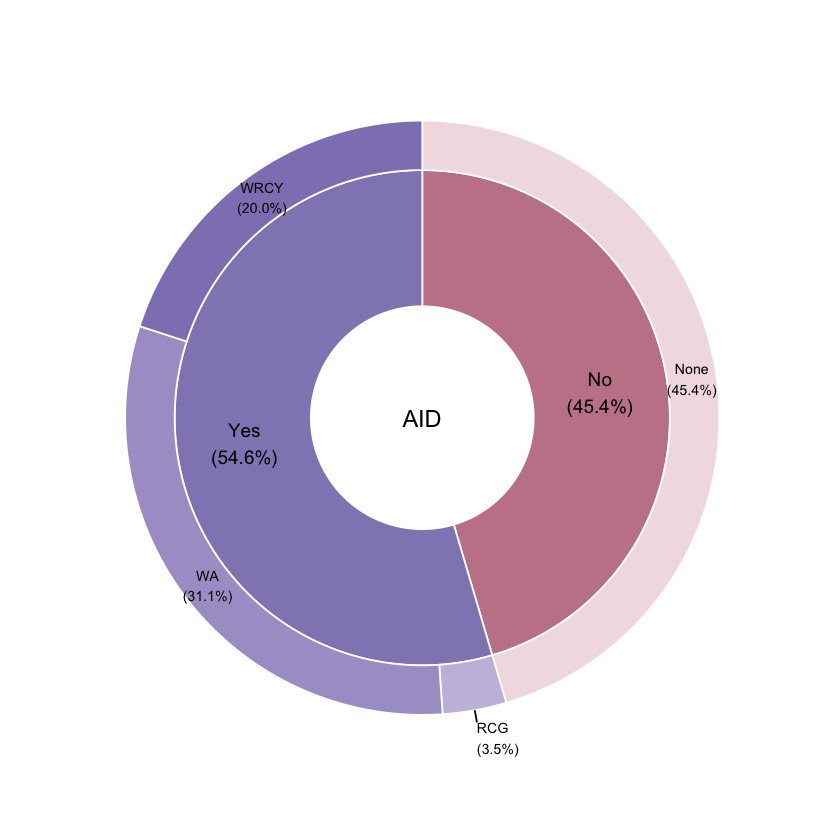

In [39]:
#png("figs_paper/pie_AID.png") # width = 600, height=350

pie_querico <- PieDonutCustom(AID_motif_summ,aes(AID,Motifs, count=Percentage),#start=3*pi/2,maxx=1.7,
               palette_name = "purpleish", ratioByGroup = FALSE, explodeDonut=TRUE, r0 = 0.45) #explode = 2,

#dev.off()

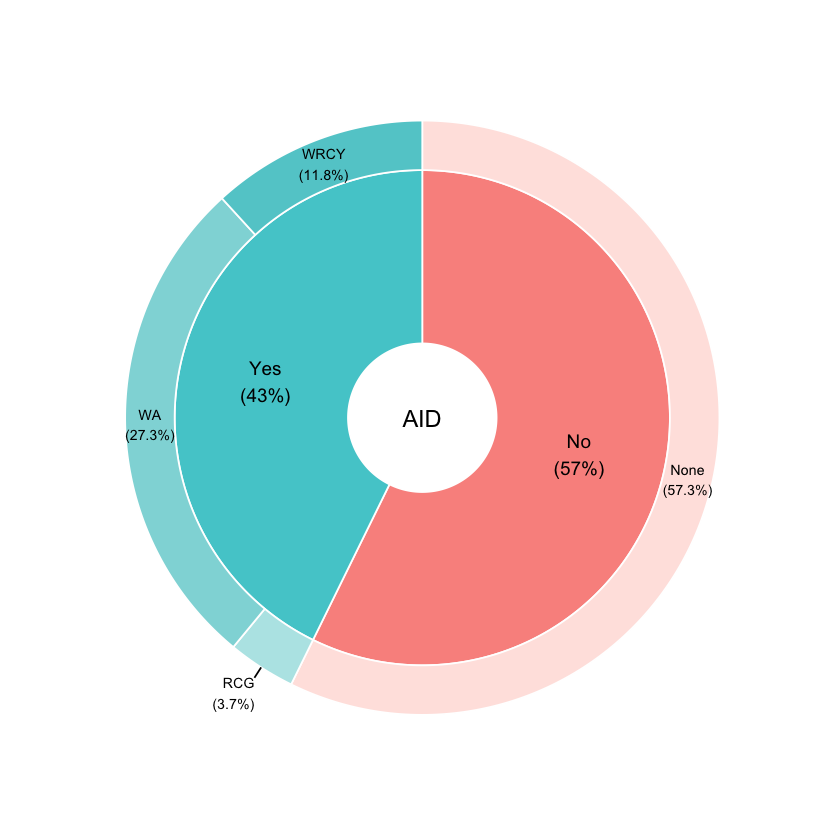

In [86]:


#pdf("figs/pie_AID.pdf") # width = 600, height=350

# Pie-Donut chart
pie_querico <- PieDonut(AID_motif_summ, aes(AID,Motifs, count=Percentage), ratioByGroup = FALSE,family = "Arial")
#dev.off()

#fig_save(pie_querico , filename = ("figs/pie_AID"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

### Compare CLL and FL (delete only for presentation purpose)

In [47]:
diagnosis <- c("FL", "FL", "CLL","CLL")
SHM_ongoing <- c("Positive", "Negative", "Positive", "Negative")
n <- c(12,7,0,5)

FL_CLL <- data.frame(diagnosis, SHM_ongoing,n) %>% group_by(diagnosis) %>% mutate(Percentage= n * 100 / sum(n)) %>%
        dplyr::mutate(diagnosis = factor(diagnosis,
                                     levels = c("FL","CLL"))) %>%
                dplyr::mutate(SHM_ongoing = factor(SHM_ongoing,
                                     levels = c("Positive","Negative")))
FL_CLL 

diagnosis,SHM_ongoing,n,Percentage
<fct>,<fct>,<dbl>,<dbl>
FL,Positive,12,63.15789
FL,Negative,7,36.84211
CLL,Positive,0,0.00000
CLL,Negative,5,100.00000


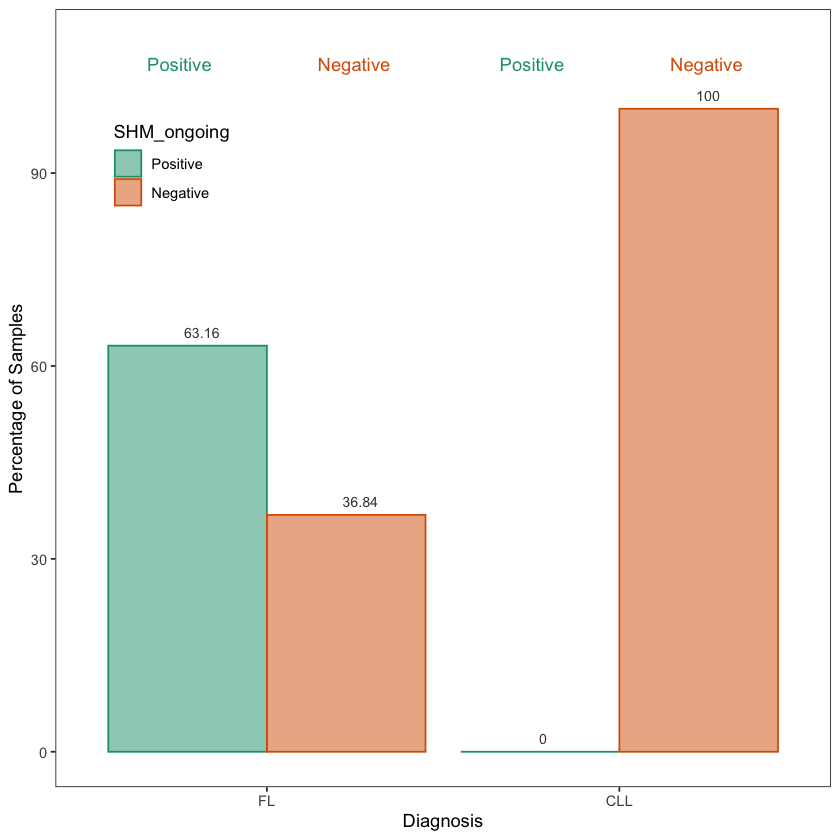

In [48]:
# coloured barplot
shM_ong <- ggplot(FL_CLL, aes(x = diagnosis, y = Percentage, fill = SHM_ongoing, colour = SHM_ongoing)) + 
  geom_bar(stat = "identity", position = "dodge", alpha = 0.5)  +
  labs(x="Diagnosis", y="Percentage of Samples") +
  theme_bw() + 
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank()) +
  theme(legend.position = c(0.15, 0.8)) +
  geom_text(aes(label=round(Percentage,2)), position = position_dodge(0.90), size = 3, 
            vjust=-0.8, hjust=0.1, colour = "gray25") +
  ylim(0, 110) +
  geom_text(aes(label=SHM_ongoing, y = 107), position = position_dodge(0.99), show.legend = FALSE) +
  scale_fill_brewer(palette = "Dark2") +
  scale_color_brewer(palette = "Dark2")

shM_ong

fig_save(shM_ong , filename = ("figs/SHM_ongoing"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

## Add clonotype data

In [1]:
clonotype <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clones_2022_01_18.csv") %>% mutate(cell = gsub(".{2}$", "", barcode)) %>% 
             select(source, cell,chain,is_cell,productive,high_confidence,umis,reads,seqConcClone, ,cluster,seqConcCount)  %>% 
             mutate(gene=case_when(chain == "IGH" ~ "HC",
                                     chain == "IGK" | chain == "IGL" ~ "LC",
                                    TRUE ~ "NA"))

ERROR: Error in read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clones_2022_01_18.csv") %>% : could not find function "%>%"


In [50]:
#test

In [51]:
test <- readRDS("~/repositories/FL_10X_2/250_Clonotypes/outs/clonesB_20210803.rds") %>% mutate(cellbarcode = gsub(".{2}$", "", cell),cell = gsub("^.{4}", "", cellbarcode)) %>% 
             select(source, cell,chain,is_cell,productive,high_confidence,umis,reads,cloneAA)  %>% #seqConcClone, ,cluster,seqConcCount
             mutate(gene=case_when(chain == "IGH" ~ "HC",
                                    TRUE ~ "LC"))

### (Trully) negative cells for scSHM

In [52]:
print("number of cells in scRNA-seq")
clonotype %>% select(source, cell) %>% unique() %>% str()

[1] "number of cells in scRNA-seq"
'data.frame':	50370 obs. of  2 variables:
 $ source: chr  "K4B" "K4B" "K4B" "K4B" ...
 $ cell  : chr  "AAACCTGAGAGACGAA" "AAACCTGAGTAACCCT" "AAACCTGAGTGATCGG" "AAACCTGCAAGTCTAC" ...


In [53]:
#cellbarcode from BCR seq
df_seq_all <- Sys.glob("input/output_shm_20220819/*/consensus/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x))
  })

cell_bcr <- df_seq_all %>% pull(cell) %>% unique()
print("number of cells in scBCR-seq")
df_seq_all %>% pull(cell) %>% unique() %>% str()

[1] "number of cells in scBCR-seq"
 chr [1:34299] "AAACCTGAGAGACGAA" "AAACCTGAGCCACGTC" "AAACCTGAGTAACCCT" ...


In [54]:
clonotype %>% filter(cell %in% cell_bcr) %>% pull(cell) %>% unique() %>% str

 chr [1:30686] "AAACCTGAGAGACGAA" "AAACCTGAGTAACCCT" "AAACCTGAGTGATCGG" ...


In [55]:
# positive cells
positive_cell <- df_summary %>% pull(cell) %>% unique() 

In [56]:
# false positive
false_positives <- read.csv("output/false_positives_cell_scSHM_K45678B.csv")

In [57]:
str(false_positives)

'data.frame':	28436 obs. of  2 variables:
 $ experiment: chr  "K4B" "K4B" "K4B" "K4B" ...
 $ cell      : chr  "AAACCTGAGAGACGAA" "ATCTACTAGCTCTCGG" "CACACAATCGTAGATC" "CGAGCCACACGTCTCT" ...


In [58]:
#trully negative cells with same quality as scSHM positive cells
trully_negative <- clonotype %>% filter(cell %in% cell_bcr, umis >= 10 & reads >= 25 ) %>% filter(!cell %in% positive_cell) %>% #filter positive cell out
select(source, cell) %>% unique() %>%   anti_join(false_positives) #filter false positice cells out

print("number of trully negative cells (same quality) in scBCR-seq")
str(trully_negative)

Joining with `by = join_by(cell)`


[1] "number of trully negative cells (same quality) in scBCR-seq"
'data.frame':	3431 obs. of  2 variables:
 $ source: chr  "K4B" "K4B" "K4B" "K4B" ...
 $ cell  : chr  "AAACCTGTCACGAAGG" "AAACGGGAGTGGCACA" "AAACGGGGTCTAGCGC" "AAAGCAAGTACTTAGC" ...


In [59]:
write.csv(trully_negative, "output/trully_negative_cells.csv", row.names=FALSE)

In [60]:
#add clonotype data (fist add gene column in df summary for joining)
df_summary <- df_summary %>% mutate(gene=if_else(str_sub(subject, -2) == "HC", "HC", "LC"),source = str_sub(subject, 1, 3)) %>% left_join(clonotype, c("source","cell","gene"))

In [61]:
df_summary %>% filter(is_cell == "FALSE")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis.x,productive.x,aid_motif1,⋯,source,chain,is_cell,productive.y,high_confidence,umis.y,reads,seqConcClone,cluster,seqConcCount
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,⋯,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>,<int>


In [21]:
df_summary %>% filter(cell == "CAGCCGACACACCGCA")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
K7B_S10000-LC,CAGCCGACACACCGCA,78,C,AG.TC,CDR1,C-G,41-50,TRUE
K7B_S10000-LC,CAGCCGACACACCGCA,154,G,AT.GT,CDR2,A-G,42-37,TRUE


In [62]:
df_summary %>% filter(is.na(seqConcClone))

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis.x,productive.x,aid_motif1,⋯,source,chain,is_cell,productive.y,high_confidence,umis.y,reads,seqConcClone,cluster,seqConcCount
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,⋯,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>,<int>
K1B_S10000-LC,TTAGGCAGTCGAACAG,10,C,TG.TG,FR1,C-T,10-9,TRUE,WRCY,⋯,K1B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K1B_S10000-LC,CTAGCCTCAATCACAC,60,C,AT.TC,FR1,C-G,11-14,TRUE,None,⋯,K1B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K1B_S10000-LC,ACTTTCACATTGTGCA,65,G,CT.CA,FR1,A-G,5-8,TRUE,WA,⋯,K1B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K1B_S10000-LC,CTAGCCTCAATCACAC,150,C,AT.TA,FR2,A-C,7-11,TRUE,WA,⋯,K1B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K1B_S144-HC,CTCGAGGCAATGACCT,33,G,GT.GT,FR1,A-G,5-6,TRUE,WA,⋯,K1B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K1B_S144-HC,GTCACAACAACGATCT,132,G,GG.CT,FR2,C-G,6-6,TRUE,None,⋯,K1B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K1B_S144-HC,GTCACAACAACGATCT,167,G,AA.TA,CDR2,C-T,6-5,TRUE,WRCY,⋯,K1B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K1B_S144-LC,TTTCCTCCACTTAAGC,4,A,AC.TC,FR1,A-G,6-7,TRUE,None,⋯,K1B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K1B_S144-LC,ATCATGGGTGGTCTCG,4,A,AC.TC,FR1,A-T,12-23,TRUE,None,⋯,K1B,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [63]:
print("Number of FALSE cells")
df_summary %>% filter(is_cell == FALSE ) %>% pull(cell) %>% unique() %>% length()

[1] "Number of FALSE cells"


[1] 0

In [64]:
df_summary %>% filter(subject == "K4B_S8934-HC")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis.x,productive.x,aid_motif1,⋯,source,chain,is_cell,productive.y,high_confidence,umis.y,reads,seqConcClone,cluster,seqConcCount
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,⋯,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>,<int>
K4B_S8934-HC,TGTCCCAGTTTGTTGG,4,G,AG.TG,FR1,A-G,18-8,TRUE,None,⋯,K4B,IGH,TRUE,TRUE,TRUE,21,18582,5,4,130
K4B_S8934-HC,TGAGAGGCAGACTCGC,9,G,CA.CT,FR1,A-G,34-69,TRUE,WA,⋯,K4B,IGH,TRUE,TRUE,TRUE,85,40086,13,4,42
K4B_S8934-HC,AGATCTGAGACCGGAT,18,G,GA.TC,FR1,A-G,6-5,TRUE,WA,⋯,K4B,IGH,TRUE,TRUE,TRUE,13,28766,32,0,18
K4B_S8934-HC,AGGCCGTGTGCGCTTG,70,G,CA.CC,FR1,A-G,5-5,TRUE,WA,⋯,K4B,IGH,TRUE,TRUE,TRUE,9,33874,6,2,119
K4B_S8934-HC,CTTTGCGTCAAGGTAA,186,C,TA.GC,FR3,C-T,22-22,TRUE,RCG,⋯,K4B,IGH,TRUE,TRUE,TRUE,60,55340,6,5,119
K4B_S8934-HC,GGACGTCTCGACCAGC,188,C,CG.TG,FR3,C-G,8-5,TRUE,None,⋯,K4B,IGH,TRUE,TRUE,TRUE,16,27612,827,5,1
K4B_S8934-HC,ACGTCAACACATCTTT,241,C,CG.TG,FR3,C-G,13-6,TRUE,None,⋯,K4B,IGH,TRUE,TRUE,TRUE,24,44434,48,0,11
K4B_S8934-HC,ACAGCCGAGCTGAAAT,247,C,AT.TG,FR3,C-T,5-6,TRUE,None,⋯,K4B,IGH,TRUE,TRUE,TRUE,8,43914,1044,5,1
K4B_S8934-HC,CTGCGGAGTTACAGAA,260,G,CA.CC,FR3,A-G,12-9,TRUE,WA,⋯,K4B,IGH,TRUE,TRUE,TRUE,118,39104,615,5,1


## Substitution type (spectro)

In [129]:
spectro <- df_summary %>% group_by(variation) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n))
spectro

variation,n,Percentage
<chr>,<int>,<dbl>
A-C,83,6.698951
A-G,459,37.046005
A-T,68,5.488297
C-G,252,20.338983
C-T,323,26.069411
G-T,54,4.358354


In [66]:
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




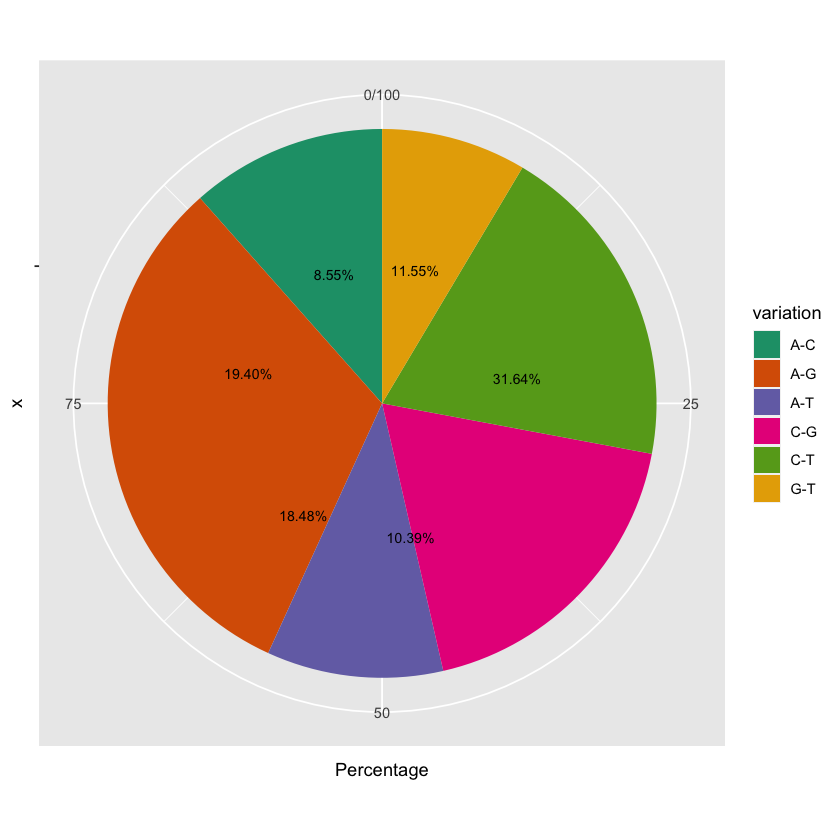

In [67]:
# pie
bp <- ggplot(spectro, aes(x="", y=Percentage, fill=variation))+
geom_bar(width = 1, stat = "identity") +
coord_polar("y", start=0) +
scale_fill_brewer(palette="Dark2") +
  geom_text(aes(y = Percentage/3 + c(0, cumsum(Percentage)[-length(Percentage)]), 
            label = percent(Percentage/100)), size=3)

bp

fig_save(bp, filename = ("figs/perc_spectro"), formats = c("pdf", "png"), width = 17, height =15, units = "cm", dpi = 320)

## Extract SHMss sequences for plotting of the events

In [72]:
df_summary %>% separate(umis, c("umi1", "umi2"), "-", convert = TRUE) %>% mutate(umis = umi1+umi2) %>% pull(umis) %>% sum()

[1] 78495

In [71]:
willow_seq <- df %>% dplyr::inner_join(df_summary %>% select(subject,cell,vgene_position_aligned)) %>% mutate(id=paste0(subject,"_",cell,"_",umi,"_",position,"_",vgene_position_aligned,"_",nucl)) %>% mutate(id_split=paste0(subject,"_",cell))
head(willow_seq)

Joining with `by = join_by(cell, vgene_position_aligned, subject)`


,cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,id,id_split
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AGCTTGACAATGGACG,AAGACGTACA,132,G,A,CA.TG,18,TRUE,V,28,28,G,CA.TG,FR1,K1B_S10000-LC,K1B_S10000-LC_AGCTTGACAATGGACG_AAGACGTACA_132_28_A,K1B_S10000-LC_AGCTTGACAATGGACG
2,AGCTTGACAATGGACG,ACCATCTTAT,132,G,G,CA.TG,16,TRUE,V,28,28,G,CA.TG,FR1,K1B_S10000-LC,K1B_S10000-LC_AGCTTGACAATGGACG_ACCATCTTAT_132_28_G,K1B_S10000-LC_AGCTTGACAATGGACG
3,AGCTTGACAATGGACG,AGGACTGGCA,132,G,A,CA.TG,27,TRUE,V,28,28,G,CA.TG,FR1,K1B_S10000-LC,K1B_S10000-LC_AGCTTGACAATGGACG_AGGACTGGCA_132_28_A,K1B_S10000-LC_AGCTTGACAATGGACG
4,AGCTTGACAATGGACG,AGGCGACCAG,132,G,A,CA.TG,15,TRUE,V,28,28,G,CA.TG,FR1,K1B_S10000-LC,K1B_S10000-LC_AGCTTGACAATGGACG_AGGCGACCAG_132_28_A,K1B_S10000-LC_AGCTTGACAATGGACG
5,AGCTTGACAATGGACG,AGTAACTGAC,132,G,A,CA.TG,23,TRUE,V,28,28,G,CA.TG,FR1,K1B_S10000-LC,K1B_S10000-LC_AGCTTGACAATGGACG_AGTAACTGAC_132_28_A,K1B_S10000-LC_AGCTTGACAATGGACG
6,AGCTTGACAATGGACG,AGTTCATCGG,132,G,G,CA.TG,43,TRUE,V,28,28,G,CA.TG,FR1,K1B_S10000-LC,K1B_S10000-LC_AGCTTGACAATGGACG_AGTTCATCGG_132_28_G,K1B_S10000-LC_AGCTTGACAATGGACG


In [94]:
willow_seq  %>% filter(depth >= 5) %>% group_by(subject,cell, vgene_position_aligned,nucl) %>% count()  %>% group_by(subject,cell, vgene_position_aligned,nucl) %>% dplyr::slice_max(n, n = 2) %>%  
filter(sum(n) >= 10) %>% pull(n) %>% sum()

[1] 111706

In [15]:
length(unique(willow_seq$id_split))

[1] 416

In [17]:
df_seq %>% filter(cell %in% willow_seq$cell & subject %in% willow_seq$subject) %>% 
right_join(willow_seq %>% select(subject,cell,umi,id),c("subject","cell","umi")) %>% str()
#%>% pull(umi) %>% unique() %>% str() # & subject %in% willow_seq$subject & 

'data.frame':	147362 obs. of  10 variables:
 $ cell             : chr  "AGCTTGACAATGGACG" "AGCTTGACAATGGACG" "AGCTTGACAATGGACG" "AGCTTGACAATGGACG" ...
 $ umi              : chr  "AAGACGTACA" "AAGACGTACA" "ACCATCTTAT" "ACCATCTTAT" ...
 $ nreads           : int  58 58 66 66 93 93 65 65 107 107 ...
 $ ref_vdj_coverage : num  1 1 1 1 1 1 1 1 1 1 ...
 $ ref_cdr_coverage : num  1 1 1 1 1 1 1 1 1 1 ...
 $ consensus        : chr  "TGCTTCAGCTGTGGGCACAAGAGGCAGCACTCAGGACAATCTCCAGCATGGCCTGGTCTCCTCTCCTCCTCAGTCTCCTCGCTCACTGCACAGGGTCCTGGGCCCAGTCTG"| __truncated__ "TGCTTCAGCTGTGGGCACAAGAGGCAGCACTCAGGACAATCTCCAGCATGGCCTGGTCTCCTCTCCTCCTCAGTCTCCTCGCTCACTGCACAGGGTCCTGGGCCCAGTCTG"| __truncated__ "TGCTTCAGCTGTGGGCACAAGAGGCAGCACTCAGGACAATCTCCAGCATGGCCTGGTCTCCTCTCCTCCTCAGTCTCCTCGCTCACTGCACAGGGTCCTGGGCCCAGTCTG"| __truncated__ "TGCTTCAGCTGTGGGCACAAGAGGCAGCACTCAGGACAATCTCCAGCATGGCCTGGTCTCCTCTCCTCCTCAGTCTCCTCGCTCACTGCACAGGGTCCTGGGCCCAGTCTG"| __truncated__ ...
 $ aligned_consensus: chr  "TGCTTCAGCTGTGGGCACAAGAGGCA

In [18]:
df_seq %>% head()

,cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGTGTTTGC,AATTGACGCG,174,1,1,TTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTC,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;15;15;15;15;15;15;16;16;16;16;16;16;16;16;17;105;106;106;107;109;109;111;112;114;114;114;114;116;117;120;120;123;123;123;123;123;124;124;126;126;126;126;127;127;127;127;128;128;128;128;128;128;128;128;129;128;127;127;127;127;127;128;128;129;129;129;129;129;130;130;130;130;130;129;129;131;131;131;132;132;132;132;129;129;129;129;131;129;129;129;130;130;129;129;129;129;129;128;128;127;125;123;122;122;122;119;118;118;118;118;117;115;115;115;114;115;113;113;113;112;41;43;44;44;44;45;44;45;45;45;45;45;46;46;45;45;45;45;45;46;45;45;45;44;44;45;44;43;43;43;43;43;44;44;45;45;45;44;44;44;43;43;41;40;40;40;40;40;39;38;37;37;34;34;34;34;34;34;35;34;34;34;34;33;33;33;33;32;32;32;33;33;33;33;33;33;33;33;33;33;33;33;33;33;31;32;32;33;33;33;33;33;33;33;33;33;31;31;30;28;28;28;29;29;29;29;29;27;26;26;26;25;25;25;26;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;26;24;24;24;23;23;23;22;21;21;21;20;20;19;19;20;20;20;20;20;19;19;19;18;18;17;17;17;16;16;16;15;15;15;15;14;14;14;13;13;12;12;12;12;12;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;10;10;10;10;10;10;10;10;10;10;10;10;9;9;8;8;8;8;8;8;8;8;8;8;7;7;7;6;6;5;5;5;5;5;5;5;5;6;7;7;7;7;7;7;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;3;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,K1B_S10000-HC
2,AAACCTGGTCCAGTAT,ACCTCGAATG,109,1,1,ATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCC

In [19]:
for (i in willow_seq$id_split) {
    df_fi <- willow_seq %>% filter(id_split == i)
    df_seq_fil <- df_seq %>% filter(cell %in% df_fi$cell & subject %in% df_fi$subject) %>% #  cell == "AAACGGGGTATTAGCC"
#                 select(umi,aligned_consensus) 
                   right_join(df_fi %>% select(subject,cell,umi,id),c("subject","cell","umi"))  %>% select(id,consensus) 
    Xfasta <- character(nrow(df_seq_fil) * 2)
    Xfasta[c(TRUE, FALSE)] <- paste0(">", df_seq_fil$id)
    Xfasta[c(FALSE, TRUE)] <- df_seq_fil$consensus
    
    writeLines(Xfasta, paste0("output/fasta_SHM_cells/consensus",i,".fasta"))
    
}

### Calculate proportion FW/CDR in events

In [35]:
df_summary %>% group_by(subregion) %>% count() %>% mutate(region=substr(subregion, 1, 2)) 

subregion,n,region
<chr>,<int>,<chr>
CDR1,152,CD
CDR2,45,CD
CDR3,91,CD
FR1,284,FR
FR2,324,FR
FR3,302,FR
FR4,41,FR


In [38]:
df_summary %>% group_by(subregion) %>% count() %>% mutate(region=substr(subregion, 1, 2)) %>% group_by(region) %>% summarize(n_event=sum(n)) %>% mutate(Percentage =n_event * 100 / sum(n_event))

region,n_event,Percentage
<chr>,<int>,<dbl>
CD,288,23.24455
FR,951,76.75545


### Calculate p-value for AID mutations between FL (WES) and FL neovariant

In [226]:
# Define the number of successes (AID mutations) for each group
AIDmutations <- c(674, 934)

# Define the total number of trials (total mutations) for each group
total <- c(834, 1239)

# Perform the proportion test
result <- prop.test(AIDmutations, total)

# Print the result
print(result)



	2-sample test for equality of proportions with continuity correction

data:  AIDmutations out of total
X-squared = 8.1437, df = 1, p-value = 0.004321
alternative hypothesis: two.sided
95 percent confidence interval:
 0.01740738 0.09123210
sample estimates:
   prop 1    prop 2 
0.8081535 0.7538337 



In [224]:
# Define the data
data <- matrix(c(674, 934, 834-674, 1239-934), nrow=2)

# Add column names
colnames(data) <- c("AID_mutations", "Non_AID_mutations")

# Add row names
rownames(data) <- c("Ig_WES", "IG_neovariant")

# Perform the chi-square test
result <- chisq.test(data)

# Print the result
print(result)



	Pearson's Chi-squared test with Yates' continuity correction

data:  data
X-squared = 8.1437, df = 1, p-value = 0.004321



In [225]:
data

,AID_mutations,Non_AID_mutations
Ig_WES,674,160
IG_neovariant,934,305


In [34]:
# Calculate the expected values
expected_values <- result$expected

# Print the expected values
print(expected_values)

# Check if all expected values are greater than 5
all_greater_than_5 <- all(expected_values > 5)
print(paste("All expected values greater than 5:", all_greater_than_5))


              AID_mutations Non_AID_mutations
Ig_WES             648.7356          623.2644
IG_neovariant      599.2644          575.7356
[1] "All expected values greater than 5: TRUE"


### Data for Hendrik

In [11]:
df_summary <- df_summary %>% left_join(df %>% select(subject,cell,vgene_position_aligned,position,context_po) %>% distinct(),by=c("subject","cell","vgene_position_aligned","context_po")) %>%
  dplyr::filter(!is.na(position))

In [198]:
#write.csv(df_summary, "output/df_summary_complete.csv", row.names=FALSE)

In [184]:
#data conversion
df_summary_tidy <- df_summary %>% 
separate(variation, into = c("variant1", "variant2"), sep = "-",remove = FALSE) %>% 
separate(umis, into = c("umis1", "umis2"), sep = "-",remove = FALSE) %>%
  mutate(original = case_when(
    nucl_po == variant1 ~ variant1,
    nucl_po == variant2 ~ variant2,
    TRUE ~ "unknown"
  )) %>%
  mutate(neovariant = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ "unknown",
    TRUE ~ NA
  )) %>%
  mutate(neovariant = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ "unknown",
    TRUE ~ NA
  )) %>%


  mutate(original2 = case_when(
    nucl_po == variant1 ~ variant1,
    nucl_po == variant2 ~ variant2,
    TRUE ~ NA
  )) %>%
  mutate(neovariant1 = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ variant1,
    TRUE ~ NA
  )) %>%
  mutate(neovariant2 = case_when(
    original == "unknown" & neovariant == "unknown" ~ variant2,
    TRUE ~ NA
  )) %>% 
  mutate(original_umis = case_when(
    nucl_po == variant1 ~ umis1,
    nucl_po == variant2 ~ umis2,
    TRUE ~ NA
  )) %>%
  mutate(neovariant1_umis = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ umis1,
    nucl_po != variant2 & nucl_po == variant1 ~ umis2,
    nucl_po != variant1 & nucl_po != variant2 ~ umis1,
    TRUE ~ NA
  )) %>%
  mutate(neovariant2_umis = case_when(
    original == "unknown" & neovariant == "unknown" ~ umis2,
    TRUE ~ NA
      )) %>% mutate(AIDmotif = paste0(aid_motif1,",",aid_motif2)) %>%
  mutate(aid_motif = case_when(
    aid_motif1 == "WRCY" | aid_motif2 == "WRCY" ~ "WRCY",
    aid_motif1 == "WA" | aid_motif2 == "WA" ~ "WA",
    aid_motif1 == "RCG" | aid_motif2 == "RCG" ~ "RCG",
    TRUE ~ NA
  )) 

In [199]:
# read data from Kees and change vgene_position_aligned `9999´ to allow posterior left_join
events_v2 <- readxl::read_xlsx("~/repositories/FL_10X_2/310_Caught_in_the_act_AID/outs/paperTables/events.V2.0.xlsx") %>% 
          mutate(vgene_position_aligned = case_when(vgene_position_aligned == 9999 ~ NA,
                                                   TRUE ~ vgene_position_aligned))

In [186]:
head(df_summary_tidy)

,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,variant1,variant2,umis,umis1,umis2,productive,aid_motif1,aid_motif2,original,neovariant,original2,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,AIDmotif,aid_motif
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,K1B_S10000-LC,AGCTTGACAATGGACG,28,G,CA.TG,FR1,A-G,A,G,12-14,12,14,TRUE,WA,None,G,A,G,A,NA,14,12,NA,"WA,None",WA
2,K1B_S10000-LC,AGCTTGACAATGGACG,56,C,CA.CA,FR1,A-C,A,C,12-14,12,14,TRUE,WA,None,C,A,C,A,NA,14,12,NA,"WA,None",WA
3,K1B_S10000-LC,CTAGCCTCAATCACAC,60,C,AT.TC,FR1,C-G,C,G,11-14,11,14,TRUE,None,None,C,G,C,G,NA,11,14,NA,"None,None",NA
4,K1B_S10000-LC,CGAGCACAGGTTCCTA,78,C,AG.TC,CDR1,C-T,C,T,20-32,20,32,TRUE,WRCY,WA,C,T,C,T,NA,20,32,NA,"WRCY,WA",WRCY
5,K1B_S144-LC,ATCATGGGTGGTCTCG,4,A,AC.TC,FR1,A-T,A,T,12-23,12,23,TRUE,None,WA,A,T,A,T,NA,12,23,NA,"None,WA",WA
6,K1B_S144-LC,TCTTTCCGTCTAGTCA,18,G,CA.TC,FR1,A-G,A,G,27-18,27,18,TRUE,WA,None,G,A,G,A,NA,18,27,NA,"WA,None",WA


#### Calculate total events and number of AID motifs per case

In [194]:
summary_by_case <- df_summary_tidy %>% mutate(case = sub(".*_(.*?)\\-.*", "\\1", subject)) %>%
  group_by(case) %>%
  summarise(
    total_events = n(), # Count total events
    aid_motif_count = sum(!is.na(aid_motif1) & aid_motif1 != "None") # Count events with AID motifs
  )

In [195]:
summary_by_case 

case,total_events,aid_motif_count
<chr>,<int>,<int>
S10000,394,201
S11770,1,1
S12500,2,0
S13530,400,202
S13553,322,215
S144,116,54
S8934,4,3


In [312]:
events_v3 <- events %>% select(-nucl_po,-`AID motif`,-productive) %>% left_join(df_summary_tidy, by=c("subject","cell","subregion","variation","context_po","umis","vgene_position_aligned")) 

In [313]:
#reorder according to Kees order
events_v3 <- events_v3 %>% select(
 order,	
  Chip,	
  Sample,
  `Ig Chain`,	
  `V(D)Jmutations`,	
  `VDJmutations`,
  `VJmutations`,
  inBoth,
  `Cell ident`,
  subject,
  cell,
  subregion,
  position,
  vgene_position_aligned,
  context_po,
  aid_motif,
  original2,
  neovariant1,
  neovariant2,
  original_umis,
  neovariant1_umis,
  neovariant2_umis,
  productive
) %>% dplyr::rename("original"="original2") 

In [314]:
str(events_v3)

tibble [1,239 × 23] (S3: tbl_df/tbl/data.frame)
 $ order                 : num [1:1239] 1 2 3 4 5 6 7 8 9 10 ...
 $ Chip                  : chr [1:1239] "K7B" "K7B" "K7B" "K7B" ...
 $ Sample                : chr [1:1239] "S10000" "S10000" "S10000" "S10000" ...
 $ Ig Chain              : chr [1:1239] "L" "H" "H" "H" ...
 $ V(D)Jmutations        : num [1:1239] 1 4 4 4 4 3 3 3 3 3 ...
 $ VDJmutations          : num [1:1239] 0 4 4 4 4 0 0 0 3 3 ...
 $ VJmutations           : num [1:1239] 1 0 0 0 0 3 3 3 0 0 ...
 $ inBoth                : chr [1:1239] "FALSE" "FALSE" "FALSE" "FALSE" ...
 $ Cell ident            : chr [1:1239] "S10000.1" "S10000.1" "S10000.2" "S10000.3" ...
 $ subject               : chr [1:1239] "K7B_S10000-LC" "K7B_S10000-HC" "K7B_S10000-HC" "K7B_S10000-HC" ...
 $ cell                  : chr [1:1239] "AAAGATGGTCCGAGTC" "AAAGCAAGTTCAGACT" "AAAGCAAGTTCAGACT" "AAAGCAAGTTCAGACT" ...
 $ subregion             : chr [1:1239] "FR1" "FR3" "FR3" "FR3" ...
 $ position              : 

In [309]:
AID_motif_summ <-events_v2 %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% mutate(AID=c("Yes","Yes","Yes","No")) %>%
                 rename("aid_motif"="Motifs")
AID_motif_summ

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,57,4.600484,Yes
WA,426,34.382567,Yes
WRCY,451,36.400323,Yes
NA,305,24.616626,No


In [319]:
WriteXLS::WriteXLS(events_v3,
                    "output/events.v3.0.xlsx" )


#### Number of false cell in cell ranger

In [9]:
clonotype <- read.csv("input/clonesMulti_AllCellsForJulieta2023_02_22.csv") #%>% mutate(cell = gsub(".{2}$", "", barcode))
             # select(source, cell,chain,is_cell,productive,high_confidence,umis,reads,seqConcClone, ,cluster,seqConcCount)  %>% 
             # mutate(gene=case_when(chain == "IGH" ~ "HC",
             #                         chain == "IGK" | chain == "IGL" ~ "LC",
             #                        TRUE ~ "NA"))

Warning message in read.table(file = file, header = header, sep = sep, quote = quote, :
“incomplete final line found by readTableHeader on 'input/clonesMulti_AllCellsForJulieta2023_02_22.csv'”


In [10]:
clonotype

.......git.annex.objects.m6.MF.SHA256E.s49465855..6e85981e00d1ba16882aca5338289403e383467bdf61caac331b9bd3b4882369.csv.SHA256E.s49465855..6e85981e00d1ba16882aca5338289403e383467bdf61caac331b9bd3b4882369.csv
<lgl>
